In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.signal import fftconvolve


### View the xcorr response map of a scaled unit circle

- define the circle image parameters
- generate the circular aperture function
- make the time series of the circle moving
  - linearly in one direction
  - 1 pixel/frame movement speed

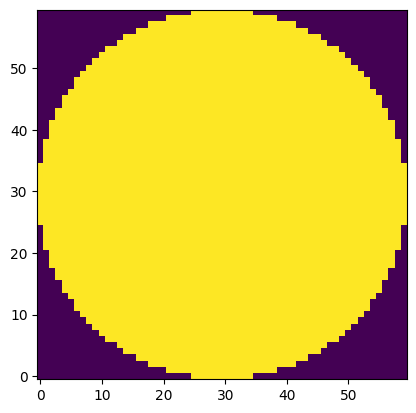

In [8]:
image_size = 60
circle_radius = 30
blank_image = np.zeros((image_size, image_size))
image_center = (image_size - 1) / 2

x_arr = np.arange(stop=image_size, dtype=float)[None,:] - image_center
y_arr = np.arange(stop=image_size, dtype=float)[:,None] - image_center

rho2d = np.sqrt(x_arr**2 + y_arr**2)

circle_image = blank_image.copy()
circle_image[rho2d <= circle_radius] = 1

plt.imshow(circle_image, origin="lower")



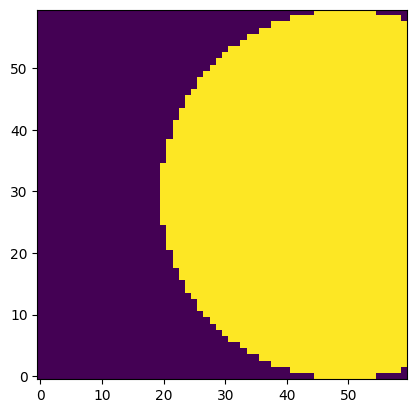

In [10]:
# Make the circle move
circle_image_series = np.zeros((image_size, image_size, circle_radius))

for i in range(circle_radius):
    moving_rho2d = np.sqrt((x_arr - i)**2 + y_arr**2)
    moving_circle = blank_image.copy()
    moving_circle[moving_rho2d <= circle_radius] = 1
    circle_image_series[:,:,i] = moving_circle
    

plt.imshow(circle_image_series[:,:,20], origin="lower")

## Do the cross-correlation and view the response map
- Do the FT transform of the entire moving circle array
- Need to figure out the zero padding
- Multiply in the Fourier domain
- Inverse transform all at once for efficiency

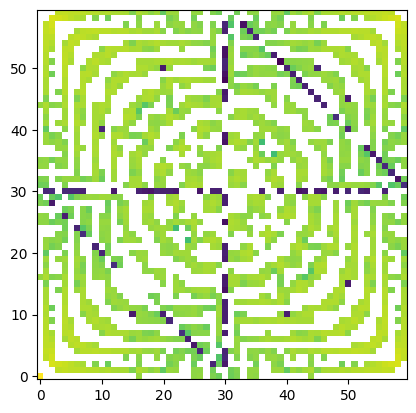

In [ ]:
circle_image_ft = np.fft.fft2(circle_image)
moving_circle_all_ft = np.fft.fft2(circle_image_series, axes=(0,1))

plt.imshow(circle_image_ft.real, origin="lower",
norm=LogNorm(min))



